# Process Mining Analysis of Market Intel

This notebook uses Process Mining through the pm4py tool to mine the flow of the market intelligence agent. It analyses the event log of that agent, discovers its process model, and uses conformance checks to compare that process model to the intended flow. 


## About the Agent

The market intelligence agent is a short-running agent that produces a market intelligence report about a given company by combiming SEC filings, stock information, and news. The agent is built as a graph. 

The following BPMN diagram describes the process that the agent uses: 
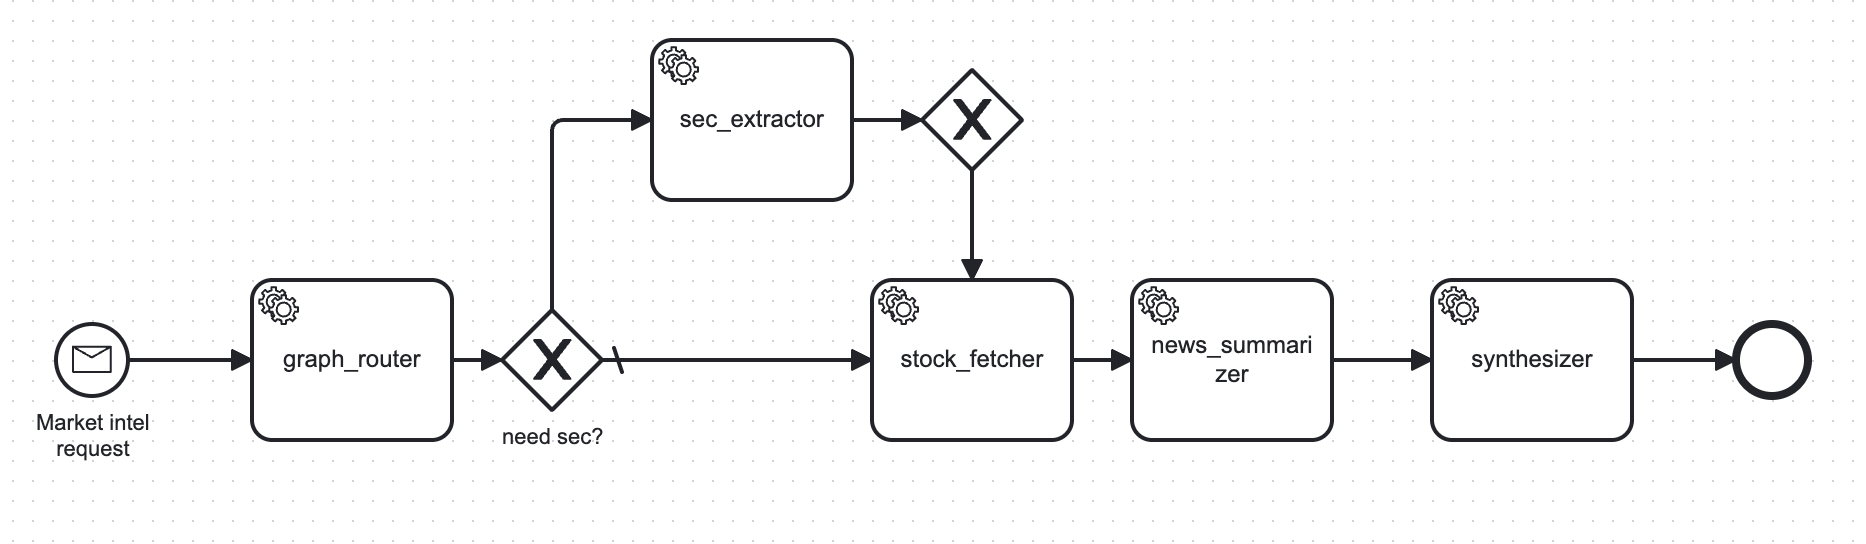


## Event Log Summary
Load in the XES event log. Dump the start and end events. Looks as expected so far. 

In [1]:
import pm4py
import pmagent_util
from pm4py.objects.bpmn.importer import importer as bpmn_importer
from pm4py.algo.conformance.alignments.petri_net import algorithm as alignments

log_xes = pm4py.read_xes('xeslogs/market_intel_agent_DEFAULT_trace.xes', return_legacy_log_object=True)
[ "start", pm4py.get_start_activities(log_xes), "end",  pm4py.get_end_activities(log_xes) ]

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/34 [00:00<?, ?it/s]

['start', {'graph_router': 34}, 'end', {'synthesizer': 34}]

## Bring into data frame

Bring XES into a Pandas dataframe.

In [2]:
df = pm4py.convert_to_dataframe(log_xes)
df

,concept:name,org:resource,time:timestamp,duration_s,trace_id,session_id,case:concept:name
0,graph_router,,2026-05-25 23:47:56.649000+00:00,1.200,becfdca21d81a1ef,6719150f-dba2-404d-9a96-434693c8f479,becfdca21d81a1ef
1,synthesizer,,2026-05-25 23:47:59.747000+00:00,3.098,becfdca21d81a1ef,6719150f-dba2-404d-9a96-434693c8f479,becfdca21d81a1ef
2,graph_router,,2026-05-25 23:44:11.494000+00:00,1.783,a58d15eb55641300,21bb86c8-3e5c-49bd-a0da-afa460db756a,a58d15eb55641300
3,sec_extractor,,2026-05-25 23:44:13.411000+00:00,1.916,a58d15eb55641300,21bb86c8-3e5c-49bd-a0da-afa460db756a,a58d15eb55641300
4,stock_fetcher,,2026-05-25 23:44:15.063000+00:00,1.652,a58d15eb55641300,21bb86c8-3e5c-49bd-a0da-afa460db756a,a58d15eb55641300
...,...,...,...,...,...,...,...
129,graph_router,,2026-05-25 23:45:55.695000+00:00,1.270,235d723da1b0b44d,9bcf8b63-43e0-43ac-8c76-ba4e68ba661d,235d723da1b0b44d
130,sec_extractor,,2026-05-25 23:45:57.915000+00:00,2.220,235d723da1b0b44d,9bcf8b63-43e0-43ac-8c76-ba4e68ba661d,235d723da1b0b44d
131,stock_fetcher,,2026-05-25 23:45:59.677000+00:00,1.761,235d723da1b0b44d,9bcf8b63-43e0-43ac-8c76-ba4e68ba661d,235d723da1b0b44d
132,news_summarizer,,2026-05-25 23:46:01.528000+00:00,1.851,235d723da1b0b44d,9bcf8b63-43e0-43ac-8c76-ba4e68ba661d,235d723da1b0b44d


How many total cases (or, in our case, conversational sessions) do we have? What are the most common variants (or tool paths taken) in these sessions?

The most common variants are expected mostly expected:

- *Happy path*: graph_router->sec_extractor->stock_fetcher->news_summarizer->synthesizer
- *Happy path with SEC skipped*: graph_router->sec_extractor->stock_fetcher->news_summarizer->synthesizer
- *Irrelevant path, a bit more cases than expected*: graph_router->synthesizer


In [3]:
pmagent_util.dump_variants(df)

Number of cases 34

Frequent variants
15 graph_router->stock_fetcher->news_summarizer->synthesizer
12 graph_router->sec_extractor->stock_fetcher->news_summarizer->synthesizer
7 graph_router->synthesizer

All variants
15 graph_router->stock_fetcher->news_summarizer->synthesizer
12 graph_router->sec_extractor->stock_fetcher->news_summarizer->synthesizer
7 graph_router->synthesizer

All variants, stutter removed
15 graph_router->stock_fetcher->news_summarizer->synthesizer
12 graph_router->sec_extractor->stock_fetcher->news_summarizer->synthesizer
7 graph_router->synthesizer


## Discovery

From the event log, discover the process. For comparison, bring in our intended model so it can be compared. Recall, we drew our intended model as a BPMN process using bpmn.io open-source editor.

To discover the process, we use the inductive miner. The Inductive Miner uses a top-down, divide-and-conquer approach that recursively breaks the event log down into standard workflow structures: sequences, loops, exclusive-or (XOR) choices, and parallel paths. By default, it guarantees a mathematically sound model that fits all the cases in the log. However, to achieve this perfect fitness, it tends to overgeneralize, meaning it can create a model that is highly structured but occasionally too permissive. Fortunately, the algorithm can be configured to filter out infrequent variants and tolerate noise.

We visualize these models using both standard BPMN and the more academically focused Petri Net. We include Petri Nets because they are the foundational language of process mining theory, allowing us to mathematically demonstrate concurrency, states, and token-based playback."

*Findings*: notice how similar the intended and discovered models are. The main difference is the "irrelevant" path that takes us directly from group_router to synthesizer. This path occurs when the user asks a question not related to market intelligence. Our intended model skips this path because it is considered too rare. Keep it simple!


Intended BPMN model


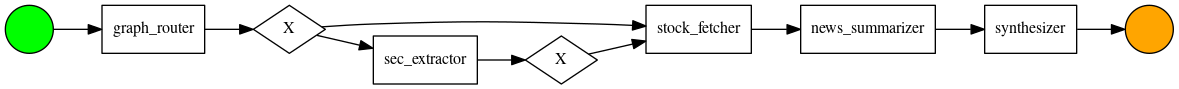

Discovered BPMN model


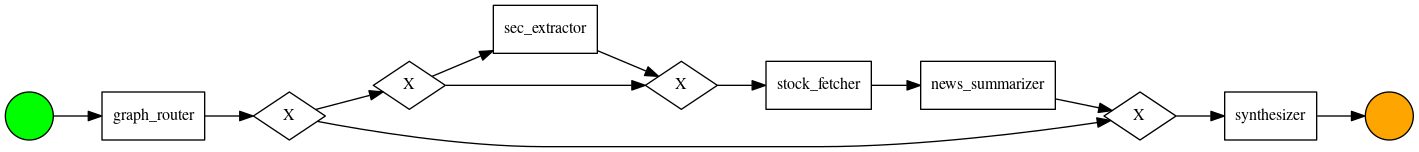

Intended Petri net


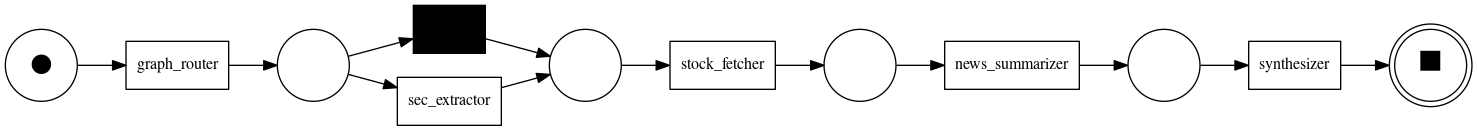

Discovered Petri net


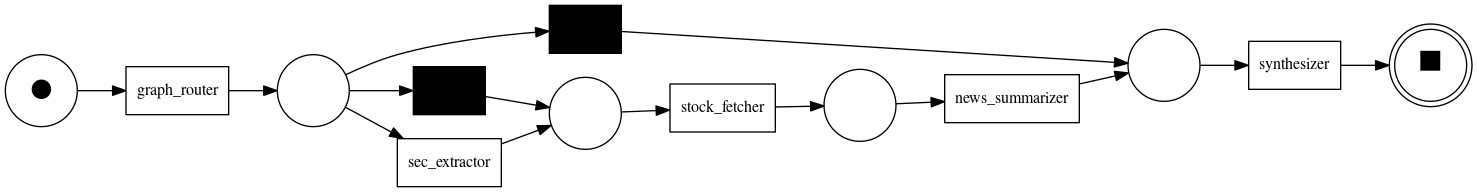

In [4]:
intended_bpmn_model = bpmn_importer.apply("../agents/market_intel_graph/intended_flow.bpmn")
intended_pn_net, intended_pn_im, intended_pn_fm = pm4py.convert_to_petri_net(intended_bpmn_model)

discovered_bpmn_model = pm4py.discover_bpmn_inductive(df)
disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm  = pm4py.discover_petri_net_inductive(df)

print("Intended BPMN model")
pm4py.view_bpmn(intended_bpmn_model)
print("Discovered BPMN model")
pm4py.view_bpmn(discovered_bpmn_model)
print("Intended Petri net")
pm4py.view_petri_net(intended_pn_net, intended_pn_im, intended_pn_fm)
print("Discovered Petri net")
pm4py.view_petri_net(disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm)


We try out a few additional mining algorithms. 

The first is to run inductive with "less noise". 

We also run the Heuristic Miner. The Inductive Miner uses a top-down approach that forces raw event logs into strict, mathematically sound structural blocks, which guarantees no deadlocks but often sacrifices precision by overgeneralizing allowable paths. In contrast, the Heuristic Miner takes a pragmatic, statistical approach based on frequency thresholds and activity dependencies, making it vastly superior at filtering out real-world noise and preserving precise agent paths. However, because the Heuristic Miner maps local dependencies instead of rigid global blocks, it does not guarantee a mathematically sound model, presenting a direct trade-off between structural perfection and practical diagnostic clarity.



Discovered Petri net - less noise


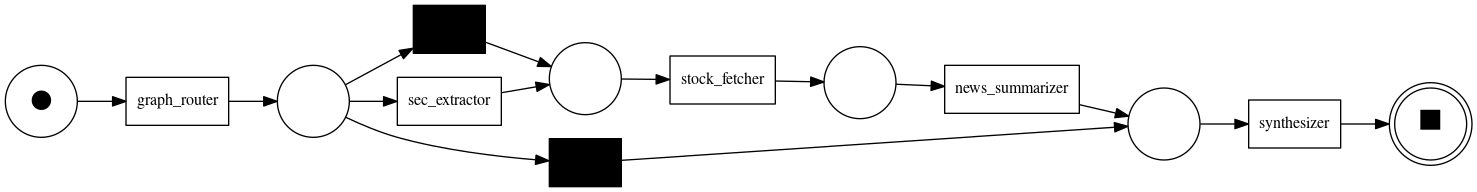

Discovered Petri net - heuristic


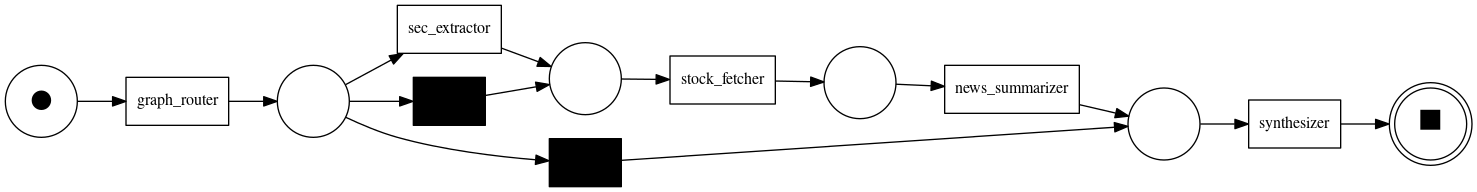

Process tree


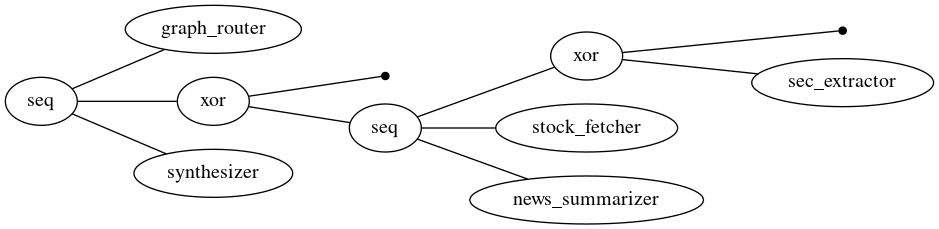

DFG


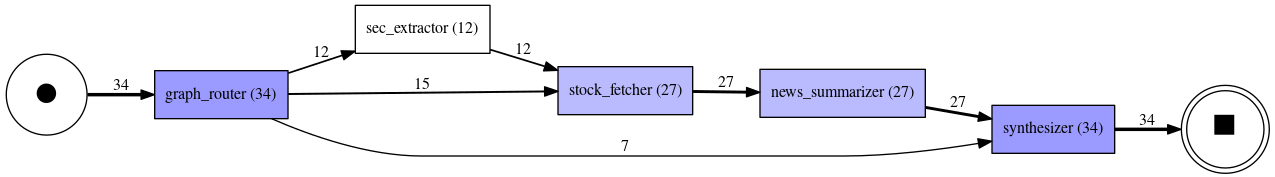

Heuristic net


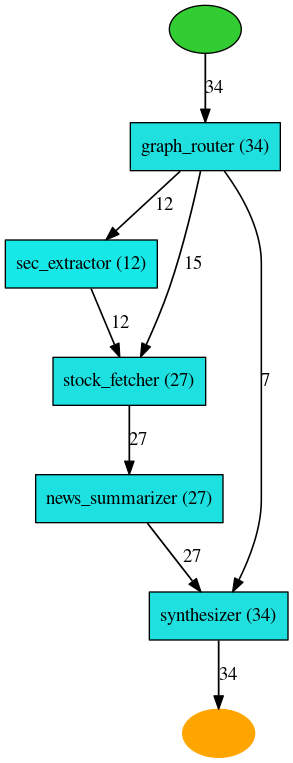

Footprints


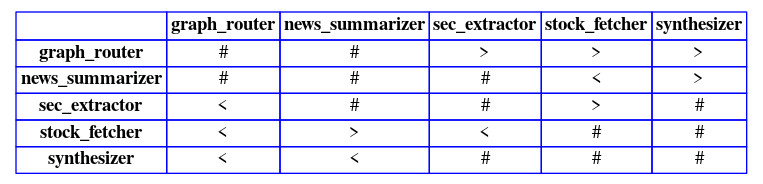

In [5]:
disc_pn_ind_quiet_net, disc_pn_ind_quiet_im, disc_pn_ind_quiet_fm  = pm4py.discover_petri_net_inductive(df, 0.8)
disc_pn_heu_net, disc_pn_heu_im, disc_pn_heu_fm  = pm4py.discover_petri_net_heuristics(df)
process_tree = pm4py.discover_process_tree_inductive(df)
dfg, start_activities, end_activities = pm4py.discover_dfg(df)
map=pm4py.discover_heuristics_net(df)
footprints = pm4py.discover_footprints(df)

print("Discovered Petri net - less noise")
pm4py.view_petri_net(disc_pn_ind_quiet_net, disc_pn_ind_quiet_im, disc_pn_ind_quiet_fm)
print("Discovered Petri net - heuristic")
pm4py.view_petri_net(disc_pn_heu_net, disc_pn_heu_im, disc_pn_heu_fm)
print("Process tree")
pm4py.view_process_tree(process_tree)
print("DFG")
pm4py.view_dfg(dfg, start_activities, end_activities)
print("Heuristic net")
pm4py.view_heuristics_net(map)
print("Footprints")
pm4py.view_footprints(footprints)

## Conformance

Now we use pm4py conformance tools to assess how well the event log aligns with our intended model. We compare that to the discovered model. 

We look at fitness and precision. Notice our fitness is 95 percent. The discovered model has 100 percent fit. 

Both models are 100 precise, meaning they do not allow traces that are not in the log. TODO ...

In [6]:
[ 
    pm4py.fitness_token_based_replay(df, intended_pn_net,intended_pn_im,intended_pn_fm),
    pm4py.fitness_token_based_replay(df, disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm ),
    pm4py.precision_token_based_replay(df, intended_pn_net,intended_pn_im,intended_pn_fm),
    pm4py.precision_token_based_replay(df, disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm )
]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/6 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/6 [00:00<?, ?it/s]

[{'perc_fit_traces': 79.41176470588235,
  'average_trace_fitness': 0.9313725490196079,
  'log_fitness': 0.9617486338797814,
  'percentage_of_fitting_traces': 79.41176470588235},
 {'perc_fit_traces': 100.0,
  'average_trace_fitness': 1.0,
  'log_fitness': 1.0,
  'percentage_of_fitting_traces': 100.0},
 1.0,
 1.0]

95 percent fit is good, but what did not fit?

In [19]:
import importlib
importlib.reload(pmagent_util)

#TODO remove

<module 'pmagent_util' from '/home/ec2-user/SageMaker/tmls/pm-for-agents/notebooks/pmagent_util.py'>

In [20]:
pmagent_util.dump_conformance_diagnostics(df, intended_pn_net,intended_pn_im,intended_pn_fm, "token")

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

=== NON-COMPLIANT AGENT TRACE AUDIT (TOKEN METHOD) ===

❌ Case ID: ce395585264e5b98 (Index: 4)
   Execution Trace: (graph_router, synthesizer)
   Compliance Issue: The agent broke sequence rules. It attempted to execute 
                     'synthesizer' before prerequisite phase gates opened/closed.
   Replay Metrics:     Missing Tokens: 1 | Stranded Tokens: 1

❌ Case ID: c68a4a37dfefdc7a (Index: 7)
   Execution Trace: (graph_router, synthesizer)
   Compliance Issue: The agent broke sequence rules. It attempted to execute 
                     'synthesizer' before prerequisite phase gates opened/closed.
   Replay Metrics:     Missing Tokens: 1 | Stranded Tokens: 1

❌ Case ID: ac7f7af2cbb8bec7 (Index: 17)
   Execution Trace: (graph_router, synthesizer)
   Compliance Issue: The agent broke sequence rules. It attempted to execute 
                     'synthesizer' before prerequisite phase gates opened/closed.
   Replay Metrics:     Missing Tokens: 1 | Stranded Tokens: 1

❌ Case ID: a6

In [ ]:
pmagent_util.dump_conformance_diagnostics(df, intended_pn_net,intended_pn_im,intended_pn_fm, "alignment")

Also play with alignments.

In [10]:
pm4py.fitness_alignments(df, intended_pn_net,intended_pn_im,intended_pn_fm)

aligning log, completed variants ::   0%|          | 0/3 [00:00<?, ?it/s]

{'percFitTraces': 79.41176470588235,
 'averageFitness': 0.9313725490196081,
 'percentage_of_fitting_traces': 79.41176470588235,
 'average_trace_fitness': 0.9313725490196081,
 'log_fitness': 0.9481406530436284}

In [8]:
alignments = pm4py.conformance_diagnostics_alignments(df, intended_pn_net,intended_pn_im,intended_pn_fm)

for idx, alignment in enumerate(alignments):
    if alignment['fitness'] < 1.0:
        print(alignment)

aligning log, completed variants ::   0%|          | 0/3 [00:00<?, ?it/s]

{'alignment': [('graph_router', 'graph_router'), ('>>', None), ('>>', 'stock_fetcher'), ('>>', 'news_summarizer'), ('synthesizer', 'synthesizer')], 'cost': 20001, 'visited_states': 5, 'queued_states': 13, 'traversed_arcs': 13, 'lp_solved': 2, 'fitness': 0.6666666666666667, 'bwc': 60001}
{'alignment': [('graph_router', 'graph_router'), ('>>', None), ('>>', 'stock_fetcher'), ('>>', 'news_summarizer'), ('synthesizer', 'synthesizer')], 'cost': 20001, 'visited_states': 5, 'queued_states': 13, 'traversed_arcs': 13, 'lp_solved': 2, 'fitness': 0.6666666666666667, 'bwc': 60001}
{'alignment': [('graph_router', 'graph_router'), ('>>', None), ('>>', 'stock_fetcher'), ('>>', 'news_summarizer'), ('synthesizer', 'synthesizer')], 'cost': 20001, 'visited_states': 5, 'queued_states': 13, 'traversed_arcs': 13, 'lp_solved': 2, 'fitness': 0.6666666666666667, 'bwc': 60001}
{'alignment': [('graph_router', 'graph_router'), ('>>', None), ('>>', 'stock_fetcher'), ('>>', 'news_summarizer'), ('synthesizer', 'synt

aligning log, completed variants ::   0%|          | 0/3 [00:00<?, ?it/s]

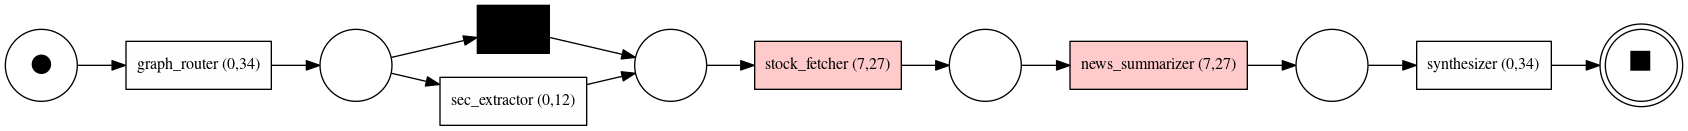

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

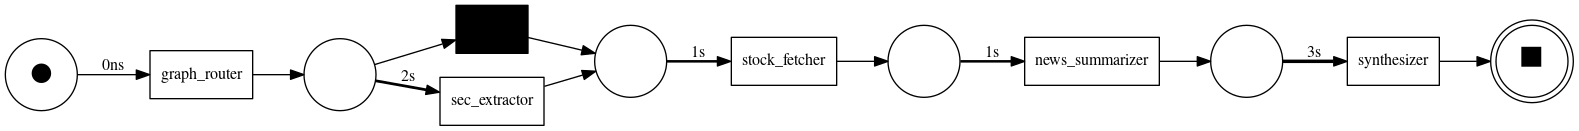

In [7]:
from pm4py.visualization.petri_net import visualizer as pn_visualizer
gviz = pn_visualizer.apply(intended_pn_net,intended_pn_im,intended_pn_fm,
                           log=df, variant=pn_visualizer.Variants.ALIGNMENTS)
pn_visualizer.view(gviz)

gviz2 = pn_visualizer.apply(
    intended_pn_net, 
    intended_pn_im, 
    intended_pn_fm,
    log=df, 
    variant=pn_visualizer.Variants.PERFORMANCE
)

pn_visualizer.view(gviz2)

## Findings and Recommendations
Our agent is implemented as a graph, so the path it follows during execution is bound by that graph model. When we represent that graph as a process model, we find that it scores high on fitness and precision.

All process models, even ones with strict flow, are subject to drift. We found one variant ... TODO .. but it's like an error case. In reality, let's introduce some more stutter.... 